# Stockholm Airbnb Market Analysis
**Project by: Faith Kangogo**

---

## Objective

This project examines the short-term rental market in Stockholm to identify the drivers of nightly price and charactarise the host landscape. The goal is to surface patterns useful to a new host setting a competitive price, or to a platform team monitoring market health. 

## Data
Data Source: Inside AirBnb (Stockholm, 29th September 2025)
Link: https://insideairbnb.com/get-the-data/

One row per active listing, covering price, location, room type, host attributes, and review activity. Prices are nightly rates in SEK. 
Listings above the 99th percentile and zero-price rows are excluded as outliers. 


**Business questions we will answer:**
1. How are prices distributed across the city, and which neighbourhoods are most expensive?
2. How does price vary by room type (entire home vs private room vs shared)?
3. What is the relationship between price and listing characteristics?
4. **Hypothesis test:** Do "Superhosts" charge significantly more than regular hosts?
5. Which hosts run the largest operations (professional vs casual hosts)?


## Approach
Data is queried in SQL(SQLite) for extraction and aggregation, then analysed and visualized in Python. 
A two-sample t-test assesses whether Superhost status is associated with higher pricing. 


**Skills demonstrated:**
- SQL queries via SQLite (filtering, aggregation, grouping)
- Python data wrangling with pandas (cleaning messy price data)
- Data visualization with matplotlib & seaborn
- Hypothesis testing with scipy
- Business insight communication

## Key Findings
* -Add here after completing *

---

---
## 1. Environment Setup & Data Loading

In [ ]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

#Plot styling
sns.set_theme(style='whitegrid', palette='rocket')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

print('Libraries loaded successfully')

Libraries loaded successfully


In [ ]:

df = pd.read_csv('listings.csv.gz')

print(f'Loaded {df.shape[0]:,} listings with {df.shape[1]} columns')
print('\nFirst few column names:')
print(list(df.columns)[:20])

Loaded 4,955 listings with 79 columns

First few column names:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url']


In [23]:
#Closer overview of the data
pd.set_option('display.max_columns',None)
df. head(5)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,is_superhost
0,164448,https://www.airbnb.com/rooms/164448,20250929042406,2025-09-29,city scrape,Double room in central Stockholm with Wi-Fi,I am renting out a nice double room on the top...,NaN,https://a0.muscache.com/pictures/f56d8d10-a7fa...,784312,https://www.airbnb.com/users/show/784312,Li,2011-07-06,"Stockholm, Sweden","I am a recently retired lady, who has two room...",within an hour,100%,100%,t,https://a0.muscache.com/im/users/784312/profil...,https://a0.muscache.com/im/users/784312/profil...,Södermalm,2.0,2.0,"['email', 'phone']",t,t,NaN,Södermalms,NaN,59.31389,18.06087,Private room in rental unit,Private room,2,1.0,1 shared bath,1.0,2.0,"[""Outdoor playground"", ""Heating"", ""Shared back...",917.0,2,120,2.0,2.0,120.0,120.0,2.0,120.0,NaN,t,24,53,83,169,2025-09-29,454,27,4,87,30,162,148554.0,2011-07-30,2025-09-23,4.86,4.87,4.79,4.95,4.97,4.84,4.76,NaN,f,2,0,2,0,2.63,True
1,220851,https://www.airbnb.com/rooms/220851,20250929042406,2025-09-29,city scrape,One room in appartement,Welcome!,Many restaurangs wery close and walkingdistanc...,https://a0.muscache.com/pictures/2085606/7a706...,412283,https://www.airbnb.com/users/show/412283,Fredric,2011-02-27,"Stockholm, Sweden",I am into arts yoga meditation design life rel...,a few days or more,0%,23%,f,https://a0.muscache.com/im/pictures/user/e0c05...,https://a0.muscache.com/im/pictures/user/e0c05...,Kungsholmen,2.0,4.0,"['email', 'phone']",t,t,"Stockholm, Stockholm County, Sweden",Kungsholmens,NaN,59.33351,18.03693,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Waterfront"", ""Heating"", ""Shared backyard \u2...",450.0,2,20,2.0,2.0,20.0,20.0,2.0,20.0,NaN,t,0,0,21,296,2025-09-29,66,2,0,25,1,12,5400.0,2011-09-29,2025-01-19,4.69,4.71,4.65,4.88,4.88,4.82,4.71,NaN,f,2,1,1,0,0.39,False
2,238411,https://www.airbnb.com/rooms/238411,20250929042406,2025-09-29,city scrape,Cozy apartment in central Stockholm,NaN,"Restaurants, cafés, museums, art galleries, pa...",https://a0.muscache.com/pictures/2806060/7fc68...,1250232,https://www.airbnb.com/users/show/1250232,Mia,2011-10-05,"Stockholm, Sweden",I am from Stockholm. I'm passionate about trav...,within a few hours,100%,0%,f,https://a0.muscache.com/im/users/1250232/profi...,https://a0.muscache.com/im/users/1250232/profi...,Norrmalm,1.0,1.0,"['email', 'phone']",t,t,"Stockholm, Stockholm County, Sweden",Norrmalms,NaN,59.33872,18.05131,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,2.0,"[""Heating"", ""Shower gel"", ""Bathtub"", ""Hangers""...",1073.0,1,60,1.0,1.0,60.0,60.0,1.0,60.0,NaN,t,22,49,79,79,2025-09-29,110,0,0,79,0,0,

In [16]:
#Clean list of columns
df.columns.tolist()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4955 entries, 0 to 4954
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            4955 non-null   int64  
 1   listing_url                                   4955 non-null   str    
 2   scrape_id                                     4955 non-null   int64  
 3   last_scraped                                  4955 non-null   str    
 4   source                                        4955 non-null   str    
 5   name                                          4955 non-null   str    
 6   description                                   4763 non-null   str    
 7   neighborhood_overview                         1780 non-null   str    
 8   picture_url                                   4955 non-null   str    
 9   host_id                                       4955 non-null   int64  
 10 

In [13]:
df.describe()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,neighbourhood_group_cleansed,latitude,longitude,accommodates,bathrooms,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,4.955000e+03,4.955000e+03,4.955000e+03,4951.000000,4951.000000,0.0,4955.000000,4955.000000,4955.000000,3189.000000,...,4085.000000,4085.000000,4085.000000,4085.000000,0.0,4955.000000,4955.000000,4955.000000,4955.000000,4086.000000
mean,6.984013e+17,2.025093e+13,1.978429e+08,7.068875,12.564532,NaN,59.318088,18.030057,3.502523,1.287551,...,4.860891,4.869435,4.810487,4.719907,NaN,4.620182,4.040565,0.530575,0.042987,1.280049
std,5.666998e+17,0.000000e+00,2.071420e+08,30.415664,133.107379,NaN,0.032222,0.065606,2.023216,1.091029,...,0.297532,0.308329,0.311399,0.366157,NaN,9.952706,9.927359,1.945364,0.428554,2.162293
min,1.644480e+05,2.025093e+13,4.457000e+03,1.000000,1.000000,NaN,59.231950,17.773110,1.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.730808e+07,2.025093e+13,2.449362e+07,1.000000,1.000000,NaN,59.297375,17.999478,2.000000,1.000000,...,4.840000,4.860000,4.750000,4.640000,NaN,1.000000,1.000000,0.000000,0.000000,0.180000
50%,8.745692e+17,2.025093e+13,1.003326e+08,1.000000,2.000000,NaN,59.317130,18.046900,3.000000,1.000000,...,4.950000,4.980000,4.900000,4.800000,NaN,1.000000,1.000000,0.000000,0.000000,0.500000
75%,1.181723e+18,2.025093e+13,3.595140e+08,2.000000,4.000000,NaN,59.337973,18.076503,4.000000,1.500000,...,5.000000,5.000000,5.000000,4.950000,NaN,2.000000,1.000000,0.000000,0.000000,1.540000
max,1.519717e+18,2.025093e+13,7.205346e+08,1456.000000,8775.000000,NaN,59.418950,18.191930,16.000000,50.000000,...,5.000000,5.000000,5.000000,5.000000,NaN,51.000000,51.000000,21.000000,6.000000,52.340000


---
## 2. Data Cleaning

Here, I did a few deper checks to interact with the data and have a feel of what extactly I'm working with. The `price` column which I am sure I'll be working with, comes in as text like `"SEK 1,250.00"` . I need to convert it to a number before I can analyse it. I will also be using the column that tells us whether the host is a super host or not. In the original dataset, the column is filled as t or f to mean true or false. I'd prefer to work with true or false, so I will create a new column so that i don't destroy the original dataset.

In [49]:
# Price coulumn is string, want to change to numeric
if not pd.api.types.is_numeric_dtype (df['price']):
    df['price'] = (
        df['price']
        .str.replace('SEK', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
    )

# I want the host is superhost column to be more explicit showing true or false instead of t or f
if 'host_is_superhost' in df.columns:
    df['is_superhost'] = df['host_is_superhost'].map({'t': True, 'f': False})

# Remove extreme outliers and invalid prices
# Keep only listings with a sensible price (drops free listings & luxury outliers
# that would distort averages). Cap at the 99th percentile.
price_cap = df['price'].quantile(0.99)
df_clean = df[(df['price'] > 0) & (df['price'] <= price_cap)].copy()

print(f' Cleaned data: {len(df_clean):,} listings remain')
print(f'   Price range: SEK{df_clean["price"].min():.0f} – SEK{df_clean["price"].max():.0f}')
print(f'   Median price: SEK{df_clean["price"].median():.0f}')
print(f'   Removed {len(df) - len(df_clean):,} listings (zero price or top 1% outliers)')

 Cleaned data: 3,158 listings remain
   Price range: SEK120 – SEK6750
   Median price: SEK1196
   Removed 1,797 listings (zero price or top 1% outliers)


In [33]:
#Confirming data type change for price column
df['price'].dtype

#Confirming t and f have been changed to True and False in the host_is_superhost column
df_clean[['price', 'room_type', 'is_superhost']]



,price,room_type,is_superhost
0,917.0,Private room,True
1,450.0,Private room,False
2,1073.0,Entire home/apt,False
3,779.0,Private room,True
4,2352.0,Entire home/apt,False
...,...,...,...
4950,567.0,Entire home/apt,False
4951,272.0,Private room,False
4952,657.0,Entire home/apt,False
4953,819.0,Entire home/apt,False


In [32]:
#Confirming data
df_clean['price'].describe()

count    3158.000000
mean     1502.045598
std      1061.893191
min       120.000000
25%       750.000000
50%      1195.500000
75%      1980.000000
max      6750.000000
Name: price, dtype: float64

In [26]:
# Loading into SQLite so I can write SQL queries 

conn = sqlite3.connect(':memory:')
df_clean.to_sql('listings', conn, index=False, if_exists='replace')

print('SQLite database ready — table "listings" loaded')

SQLite database ready — table "listings" loaded


---
## 3. Data Exploration

Let's get a feel for the market before diving into specific questions.

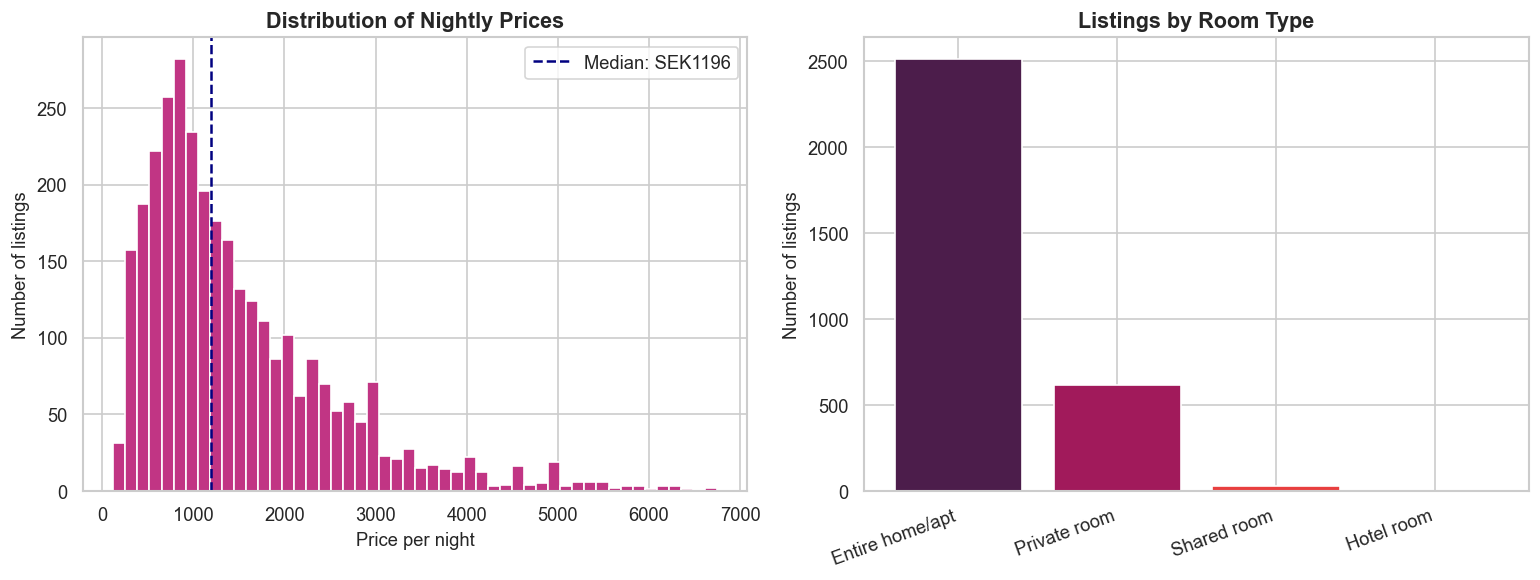

Chart saved


In [50]:
# Exploring price distribution and listings by room type
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df_clean['price'], bins=50, color='#C13584', edgecolor='white')
axes[0].axvline(df_clean['price'].median(), color='navy', linestyle='--',
                label=f'Median: SEK{df_clean["price"].median():.0f}')
axes[0].set_xlabel('Price per night')
axes[0].set_ylabel('Number of listings')
axes[0].set_title('Distribution of Nightly Prices')
axes[0].legend()

# Room type counts
room_counts = df_clean['room_type'].value_counts()
axes[1].bar(range(len(room_counts)), room_counts.values, color=sns.color_palette('rocket', len(room_counts)))
axes[1].set_xticks(range(len(room_counts)))
axes[1].set_xticklabels(room_counts.index, rotation=20, ha='right')
axes[1].set_ylabel('Number of listings')
axes[1].set_title('Listings by Room Type')

plt.tight_layout()
plt.savefig('stockholm_price_and roomtype_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

### Insights
##### a. Price Distribution
Price distribution is right skewed. Most prices appear to sit between 500 to 1500 SEK , peaking around 700 and 900 SEK, with the median price at SEK 1196.

Listings cluster in these more affordable bands, with progressively fewer high-priced listings forming a long, thin tail that extends past 6500 SEK. Because of this skew, the median is a more representative measure of a typical price than the mean, which would be inflated by the premium listings in the tail. 


##### b.Room type
Entire homes/apartments dominate the market, accounting for roughly 2500 of the 3158 listings analysed (about 79% of the total listings.)
Private homes are a distant second while the remaining 2 categories of shared and hostel rooms being almost negligeble. 
This suggets Stockholm's Airbnb market is mostly of whole-property rentals rather than casual spare-room hosting. 
This pattern may point to more commercial or investement-oriented hosting, which the host segmentation analysis later can help confirm. 
 


---
## 4. SQL Analysis: Price by Neighbourhood

**Business question:** Which neighbourhoods command the highest prices?

In [35]:
#Querying price by neighbourhood

neigh_col = 'neighbourhood_cleansed' if 'neighbourhood_cleansed' in df_clean.columns else 'neighbourhood'

query_neigh = f"""
    SELECT
        {neigh_col}              AS neighbourhood,
        COUNT(*)                 AS num_listings,
        ROUND(AVG(price), 2)     AS avg_price,
        ROUND(MIN(price), 2)     AS min_price,
        ROUND(MAX(price), 2)     AS max_price
    FROM listings
    GROUP BY {neigh_col}
    HAVING num_listings >= 30
    ORDER BY avg_price DESC
    LIMIT 15
"""

df_neigh = pd.read_sql_query(query_neigh, conn)
display(df_neigh)

,neighbourhood,num_listings,avg_price,min_price,max_price
0,Bromma,216,1755.53,300.0,6296.0
1,Södermalms,802,1730.55,270.0,6400.0
2,Norrmalms,304,1728.19,270.0,6750.0
3,Östermalms,208,1706.54,299.0,5850.0
4,Farsta,111,1532.74,270.0,5195.0
5,Hägersten-Liljeholmens,282,1450.67,120.0,5600.0
6,Kungsholmens,295,1448.38,269.0,6750.0
7,Älvsjö,123,1421.92,240.0,5850.0
8,Enskede-Årsta-Vantörs,278,1272.19,208.0,6175.0
9,Hässelby-Vällingby,109,1233.27,190.0,4800.0


#### Notes as I go
Södermalms has the most number of listings. Also among the highest average prices. (High demand, high prices type of situtation???)
It's the most expensive area , also the busiest. I'd expect a cheaper area to be more busy but it seems this is not the case. 

Neighbourhood alone doesn't seem to determine price. There's a very wide gap between min and max price in just about all neighbourhoods. Room type, size etc could have a hand. Again, average price doesn't seem to give a true reflection of typical price in a neighbourhood because of this wide gap. 



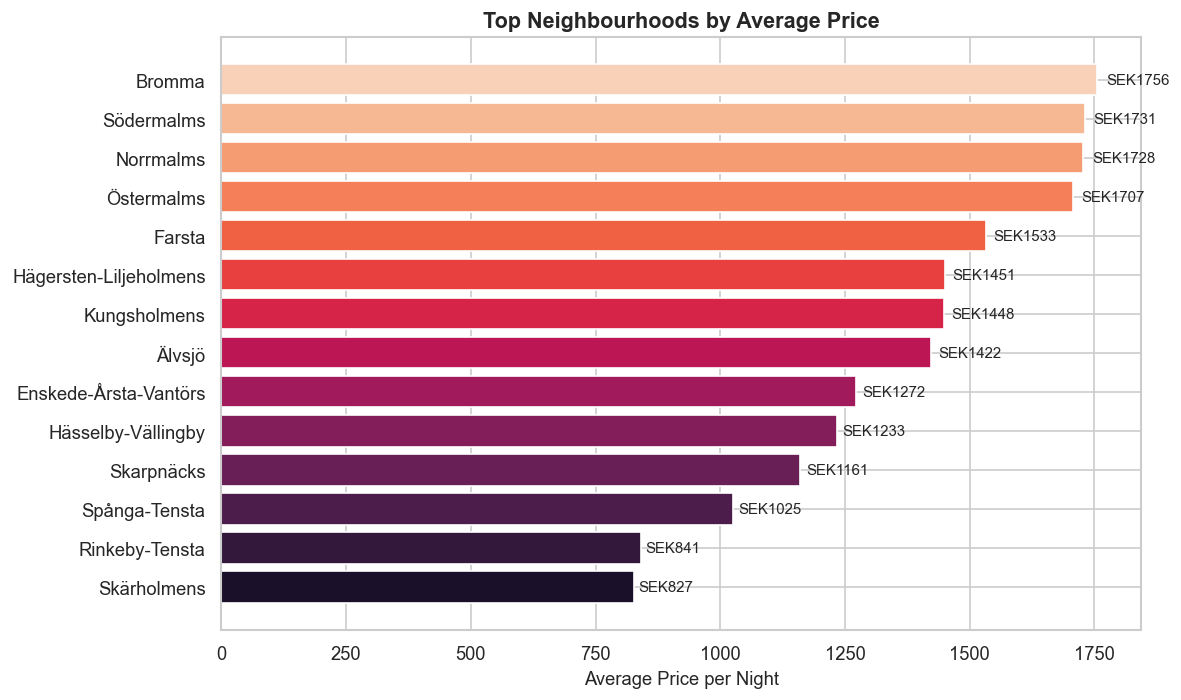

Chart saved


In [57]:
#Visualising Top neighbourhoods by average price 
fig, ax = plt.subplots(figsize=(10, 6))

colors = sns.color_palette('rocket', len(df_neigh))
bars = ax.barh(df_neigh['neighbourhood'][::-1], df_neigh['avg_price'][::-1], color=colors)
ax.set_xlabel('Average Price per Night')
ax.set_title('Top Neighbourhoods by Average Price')

for bar in bars:
    width = bar.get_width()
    ax.text(width * 1.01, bar.get_y() + bar.get_height()/2,
            f'SEK{width:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('price_by_neighbourhood.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

### Insight
Bromma, Södermalms, Norrmalms and Östermalms are the priciest neighbourhoods, with night prices averaging between 1756 SEK and 1707 SEK. 
Södermalms, Norrmalms and Östermalms are central, wealthier inner city districts which likely explains their desirability and tourist attractions. Of note is that Södermalms combines one of the highest average prices with the largest number of listings as seen previously (802 listings). This points to a market that is both premium and highly active. 

Bromma is a surburb rather than a central district, suggetsing that factors outside of centrality like property size or wealth status of the area could be driving prices. 

On the other hand, districts that are further out like Skärholmen and Rinkeby-Tensta average around 820 and 840 SEK, about half the inner city price, giving a clear contrast between inner and outer city prices. 


---
## 5. SQL Analysis: Price by Room Type

**Business question explored in this section:** How much of a premium does an entire home command over a private room?

In [39]:
# SQL Query: Price by room type 
query_room = """
    SELECT
        room_type,
        COUNT(*)                 AS num_listings,
        ROUND(AVG(price), 2)     AS avg_price,
        ROUND(AVG(number_of_reviews), 1) AS avg_reviews
    FROM listings
    GROUP BY room_type
    ORDER BY avg_price DESC
"""
df_room = pd.read_sql_query(query_room, conn)
display(df_room)

,room_type,num_listings,avg_price,avg_reviews
0,Entire home/apt,2513,1684.18,44.2
1,Private room,616,807.67,37.3
2,Shared room,28,474.89,70.6
3,Hotel room,1,303.00,44.0


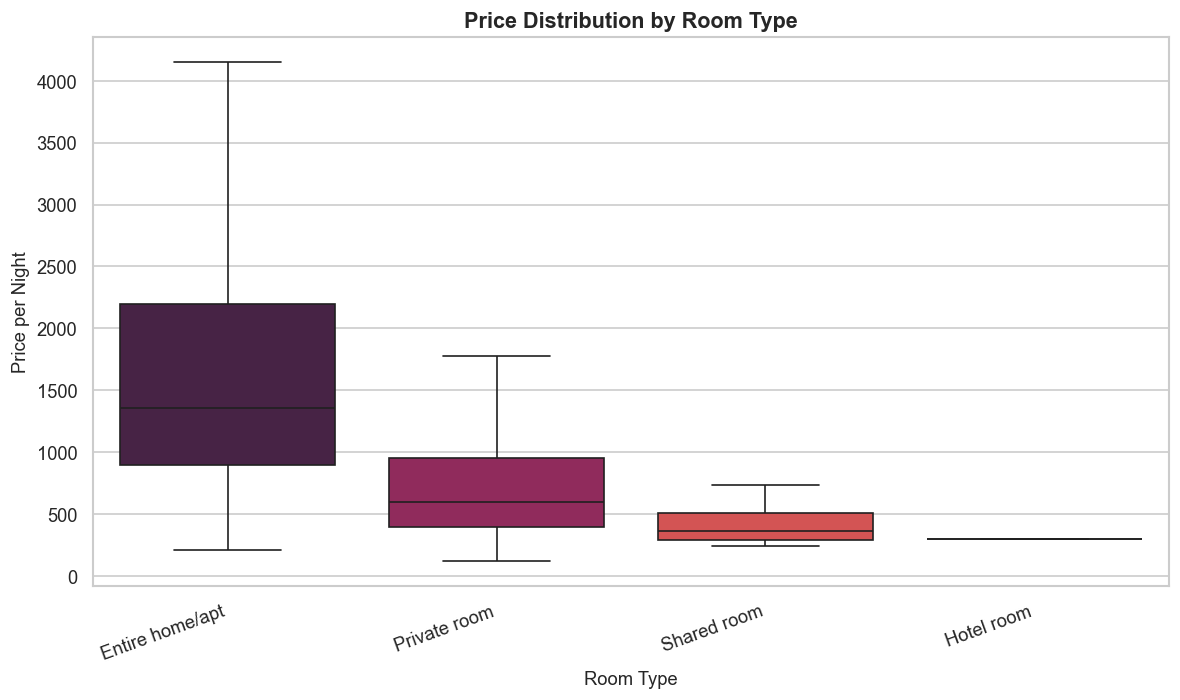

Chart saved 


In [58]:
# Visualising Price distribution by room type (box plot) 
fig, ax = plt.subplots(figsize=(10, 6))

order = df_room['room_type'].tolist()
sns.boxplot(data=df_clean, x='room_type', y='price', order=order, ax=ax, palette='rocket', showfliers=False)
ax.set_xlabel('Room Type')
ax.set_ylabel('Price per Night')
ax.set_title('Price Distribution by Room Type')
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.savefig('price_by_room_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ')

###  Insight

#### a. Room type aggregated table
Room type is a strong driver of price. Entire homes/apartments average 1,684 SEK per night  which is roughly 2.1× the 808 SEK average for private rooms. Shared rooms (475 SEK) and hotel rooms (303 SEK) are cheaper still, but with only 28 and 1 listing respectively, these two categories are too small to draw reliable conclusions from, so the meaningful comparison is between entire homes and private rooms.

#### b. Box plot
The box plot adds important nuance beyond the averages. Entire homes show a wide price distribution. The middle 50% of listings span roughly 900 to 2,200 SEK , reflecting the variety within this category (studios through to large, premium apartments). Private rooms are far more tightly clustered (roughly 400–950 SEK), indicating more consistent pricing. The two distributions barely overlap, confirming that room type alone is a meaningful predictor of price.

Read alongside the earlier finding that entire homes make up 79.6% of all listings (2,513 of 3,158), this reinforces the picture of a market oriented toward whole-property rentals at a price premium, rather than casual room-sharing. 


---
## 6. Hypothesis Test: Do Superhosts Charge More?

**Business hypothesis:**
> *Superhosts(experienced, highly-rated hosts)charge significantly higher prices than regular hosts.*

**Method:** Independent samples t-test
- **Group A:** Superhost listings
- **Group B:** Regular host listings
- **Metric:** Price per night
- **Significance level:** α = 0.05

In [52]:
# Splitting into the two groups 
if 'is_superhost' not in df_clean.columns:
    raise ValueError("No 'host_is_superhost' column found — make sure you downloaded "
                     "the DETAILED listings.csv.gz file, not the summary listings.csv")

group_super   = df_clean[df_clean['is_superhost'] == True]['price'].dropna()
group_regular = df_clean[df_clean['is_superhost'] == False]['price'].dropna()

print(f'Group A (Superhosts):    n={len(group_super):,}, mean price=SEK{group_super.mean():.2f}')
print(f'Group B (Regular hosts): n={len(group_regular):,}, mean price=SEK{group_regular.mean():.2f}')

Group A (Superhosts):    n=712, mean price=SEK1448.10
Group B (Regular hosts): n=2,426, mean price=SEK1514.29


In [53]:
# Running the t-test
t_stat, p_value = stats.ttest_ind(group_super, group_regular, equal_var=False)

alpha = 0.05
print('=' * 52)
print('HYPOTHESIS TEST RESULTS')
print('=' * 52)
print('H₀ (Null):        Mean price is equal for both groups')
print('H₁ (Alternative): Superhosts charge a different price')
print('')
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value:     {p_value:.6f}')
print(f'Alpha:       {alpha}')
print('')
diff = group_super.mean() - group_regular.mean()
if p_value < alpha:
    print(f'RESULT: Reject H₀ — the difference IS statistically significant (p < {alpha})')
    print(f'   Superhosts charge SEK{diff:+.2f} {"more" if diff > 0 else "less"} per night on average.')
else:
    print(f' RESULT: Fail to reject H₀ — the difference is NOT significant (p ≥ {alpha})')

HYPOTHESIS TEST RESULTS
H₀ (Null):        Mean price is equal for both groups
H₁ (Alternative): Superhosts charge a different price

T-statistic: -1.5135
P-value:     0.130410
Alpha:       0.05

 RESULT: Fail to reject H₀ — the difference is NOT significant (p ≥ 0.05)


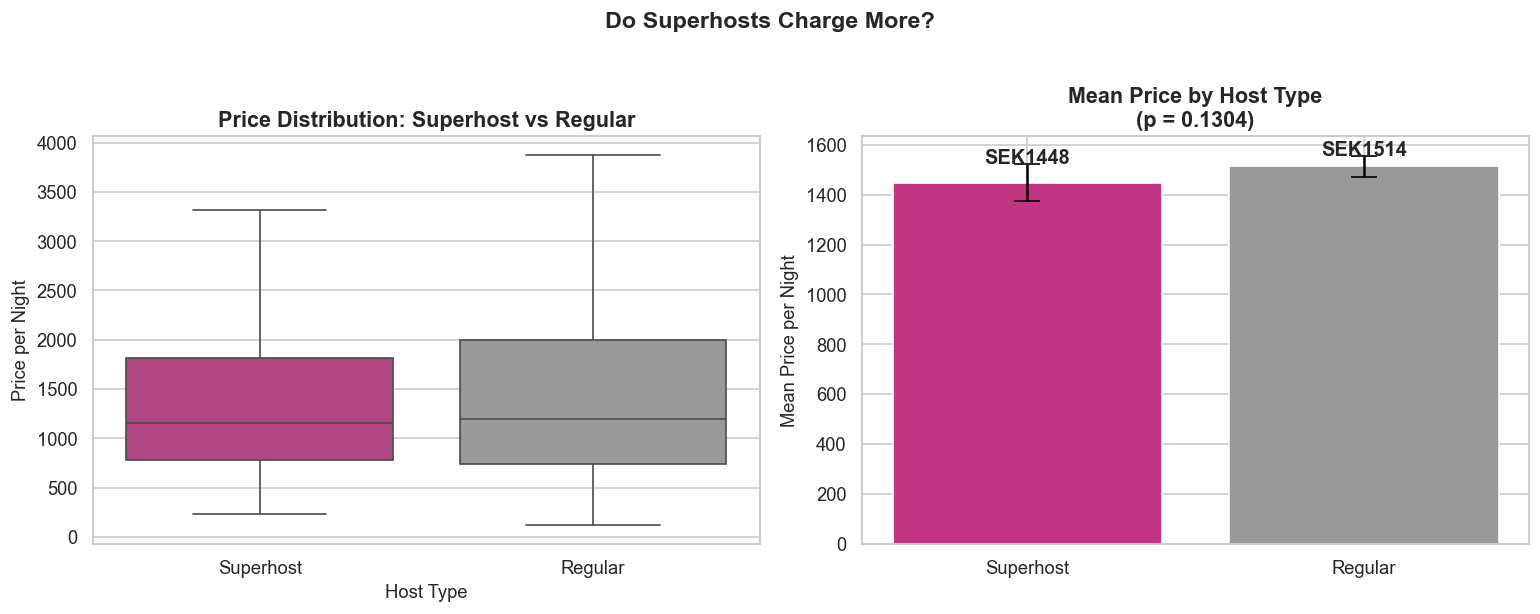

Chart saved 


In [56]:
#Visualising the comparison 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot comparison
plot_df = df_clean[df_clean['is_superhost'].notna()].copy()
plot_df['Host Type'] = plot_df['is_superhost'].map({True: 'Superhost', False: 'Regular'})
sns.boxplot(data=plot_df, x='Host Type', y='price', ax=axes[0],
            palette=['#C13584', '#999999'], showfliers=False)
axes[0].set_title('Price Distribution: Superhost vs Regular')
axes[0].set_ylabel('Price per Night')

# Mean comparison with confidence intervals
means = [group_super.mean(), group_regular.mean()]
errs  = [group_super.sem() * 1.96, group_regular.sem() * 1.96]
axes[1].bar(['Superhost', 'Regular'], means, yerr=errs, capsize=8,
            color=['#C13584', '#999999'], edgecolor='white')
axes[1].set_ylabel('Mean Price per Night')
axes[1].set_title(f'Mean Price by Host Type\n(p = {p_value:.4f})')
for i, (m, e) in enumerate(zip(means, errs)):
    axes[1].text(i, m + e + 1, f'SEK{m:.0f}', ha='center', fontweight='bold')

plt.suptitle('Do Superhosts Charge More?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('superhost_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ')

### Insight & Business Recommendation

##### Hypothesis Test: Do Superhosts Charge More?
The above two-sample t-test compared nightly prices for Superhost listings (n=712, mean 1,448 SEK) against regular-host listings (n=2,426, mean 1,514 SEK). The difference was small and not statistically significant (t = −1.51, p = 0.13). At α = 0.05 we fail to reject the null hypothesis, so there is no evidence that Superhost status is associated with a price difference in Stockholm. The overlapping box plots and confidence intervals reinforce this conclusion.

##### Interpretation & business recommendation
Superhost status does not command a price premium here. If anything, Superhosts charge marginally less. This suggests that in Stockholm, Superhost status functions less as a pricing lever and more as a trust and competitiveness signal: hosts may use it to win bookings and earn stronger reviews rather than to raise rates. For a host aiming to grow revenue, the takeaway is that pricing power likely comes from factors like room type and location (which the earlier analysis showed matter a great deal) rather than from the Superhost badge alone. 

A useful next step would be to test whether Superhosts achieve higher occupancy or review volume i.e. whether the badge drives bookings rather than price, which this dataset's review counts could begin to explore.


---
## 7. SQL Analysis: Professional vs Casual Hosts

**Business question explored in this section :** Is this a market of casual hosts renting a spare room, or professional operators with many listings?

,host_type,num_listings,avg_price
0,1 listing (Casual),1964,1636.00
1,2-5 listings (Semi-pro),496,1287.96
2,6+ listings (Professional),698,1277.25


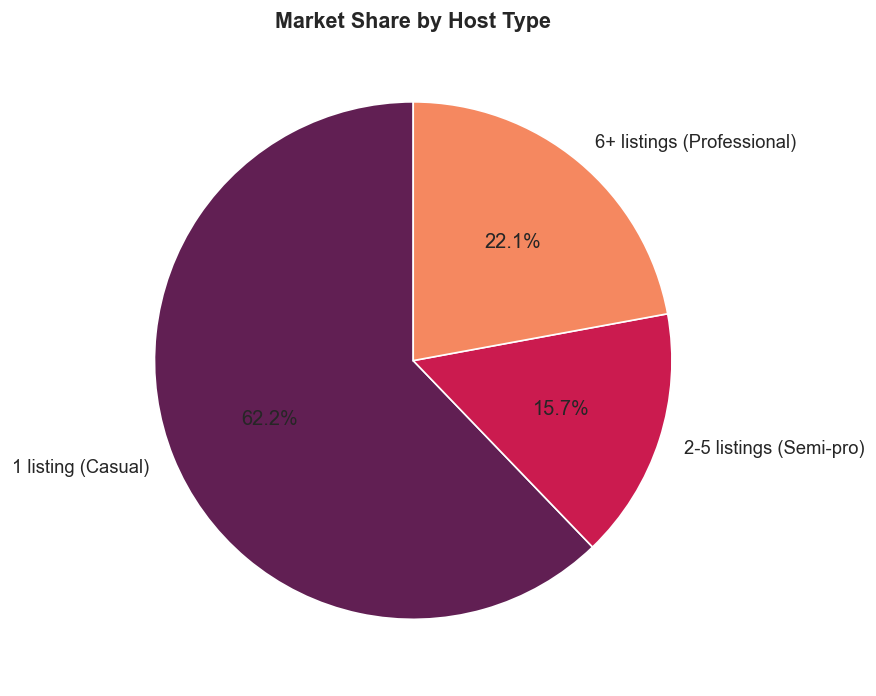

Chart saved


In [46]:
# Segment hosts by how many listings they run
host_count_col = ('calculated_host_listings_count'
                  if 'calculated_host_listings_count' in df_clean.columns
                  else 'host_listings_count')

query_hosts = f"""
    SELECT
        CASE
            WHEN {host_count_col} = 1        THEN '1 listing (Casual)'
            WHEN {host_count_col} BETWEEN 2 AND 5  THEN '2-5 listings (Semi-pro)'
            ELSE '6+ listings (Professional)'
        END AS host_type,
        COUNT(*)              AS num_listings,
        ROUND(AVG(price), 2)  AS avg_price
    FROM listings
    GROUP BY host_type
    ORDER BY avg_price DESC
"""
df_hosts = pd.read_sql_query(query_hosts, conn)
display(df_hosts)

# Pie chart of market share
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(df_hosts['num_listings'], labels=df_hosts['host_type'], autopct='%1.1f%%',
       colors=sns.color_palette('rocket', len(df_hosts)), startangle=90,
       wedgeprops={'edgecolor': 'white'})
ax.set_title('Market Share by Host Type', fontweight='bold')
plt.savefig('host_types.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved')

### Insight

##### Host Segmentation: Professional vs Casual
Segmenting hosts by the number of listings they operate shows that Stockholm's market is predominantly casual: 62.2% of listings come from single-listing hosts, with semi-professional (2–5 listings) at 15.7% and professional operators (6+ listings) at 22.1%. While a substantial professional segment exists, the market is not dominated by large-scale operators by volume.

Notably, price does not rise with professionalisation. It is infact the opposite . Casual hosts charge the most on average (1,636 SEK), while professionals charge the least (1,277 SEK). A likely explanation, consistent with the earlier room-type analysis, is that casual hosts more often list their own entire homes (larger, higher-priced), whereas professional operators run higher volumes of smaller or more standardised units priced competitively for occupancy. This would need booking or property-size data to confirm.

For a host setting strategy, this suggests that scale alone does not drive higher nightly rates; property type and size appear to matter more , backing the earlier finding that room type and location are the primary price levers.

---
### 8. Conclusions & Next Steps

##### Key findings

-Median nightly price is 1,196 SEK, right-skewed. Entire homes dominate (79.6%) and command ~2.1× the price of private rooms. 
-Central districts (Södermalm, Norrmalm, Östermalm) are priciest, with a clear centre-to-periphery gradient. Superhost status showed no significant price effect (p = 0.13). 
-The market is mostly casual hosts (62%), yet casual hosts charge more than professionals likely because they list whole homes.

##### Recommendations

-Pricing power comes from room type and location, not the Superhost badge or host scale. 
-A host should prioritise property type and area.


##### Future analysis
 Test occupancy/booking data to see if Superhost status drives volume rather than price; build a price heat map using the latitude/longitude columns.



---
*Portfolio project demonstrating end-to-end data analytics: SQL, Python, statistical testing, and business storytelling.*